In [4]:
import numpy as np
import matplotlib.pyplot as plt
from lmfit import Model, Parameters

plt.rcParams.update({
    "text.usetex": True,
    "font.family": "serif",
    'xtick.labelsize': 9,
	'ytick.labelsize': 9,
    "axes.labelsize": 10,
	'axes.titlesize': 10,
    'axes.grid': True,
	'figure.titlesize': 12,
	'legend.fontsize': 9,
	'legend.title_fontsize': 9,
	"figure.figsize": (4,3),
    "figure.autolayout": True,
    "savefig.dpi": 600,
    
})

Estimated polarizer extinction ratio: 0.1711
Estimated polarizer transmission ratio: 0.8289
[[Model]]
    Model(fitfunc)
[[Fit Statistics]]
    # fitting method   = leastsq
    # function evals   = 13
    # data points      = 5
    # variables        = 2
    chi-square         = 80.4328368
    reduced chi-square = 26.8109456
    Akaike info crit   = 17.8899230
    Bayesian info crit = 17.1087988
    R-squared          = 0.99381840
[[Variables]]
    A:  1143.79887 +/- 53.0122641 (4.63%) (init = 1000)
    p:  1.76350845 +/- 0.13426477 (7.61%) (init = 2)
[[Correlations]] (unreported correlations are < 0.100)
    C(A, p) = +0.7161
[[Model]]
    Model(<lambda>)
[[Fit Statistics]]
    # fitting method   = leastsq
    # function evals   = 5
    # data points      = 5
    # variables        = 1
    chi-square         = 22269.6500
    reduced chi-square = 5567.41250
    Akaike info crit   = 44.0077107
    Bayesian info crit = 43.6171486
[[Variables]]
    A:  90.1269998 +/- 114.784600 (127.36%) 

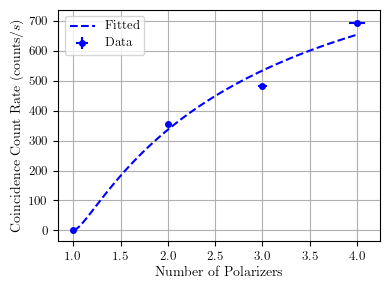

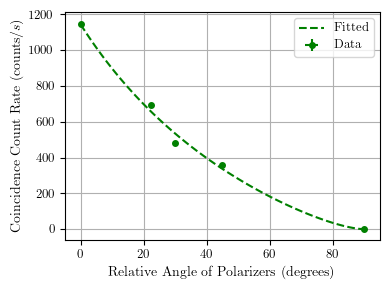

In [75]:
data = np.genfromtxt('data.csv', delimiter=',',skip_header=1)
n = np.array(data[:,0])

pol_transmission = 18340 / 22127
pol_extinction = 1 - pol_transmission
print(f"Estimated polarizer extinction ratio: {pol_extinction:.4f}")
print(f"Estimated polarizer transmission ratio: {pol_transmission:.4f}")

# count rates in counts/second
single0 = np.array(data[:,1]) / 10
single1 = np.array(data[:,2]) / 10
coinc = np.array(data[:,3]) / 10
angles = 90 / n

single0err = np.sqrt(single0 * 10) / 10 # Poisson error for count rates
single1err = np.sqrt(single1 * 10) / 10
coincerr = np.sqrt(coinc * 10) / 10
angleserr = np.ones_like(angles) * 0.5 # Assuming 0.5 degree uncertainty in angle measurements
nerr = angleserr * n**2 / 90 # Propagate angle error to n

coinc -= coinc[0]
coincerr = np.sqrt(coincerr**2 + coincerr[0]**2) # Combine errors in quadrature

max_coinc = np.max(coinc)

def fitfunc(x, A, p):
	return A * np.cos(np.radians(x))**(p*np.pi/(2*np.radians(x)))

model = Model(fitfunc)
params = Parameters()
params.add('A', value=1000)
params.add('p', value=2)
result = model.fit(coinc, params, x=angles, weights=1/coincerr)
print(result.fit_report())

angles_fit = np.linspace(angles.min(), angles.max(), 100)
coinc_fit = model.eval(result.params, x=angles_fit)

n_plot = n[:-1]
n_fit = np.linspace(n_plot.min(), n_plot.max(), 100)
coinc_n_plot = coinc[:-1]
fit_n_plot = model.eval(result.params, x=90 / n_fit)

model_null = Model(lambda x, A: A)
params_null = Parameters()
params_null.add('A', value=coinc[0])
result_null = model_null.fit(coinc, params_null, x=angles, weights=1/coincerr)
print(result_null.fit_report())

delta_chi2 = result_null.chisqr - result.chisqr
sigma = np.sqrt(delta_chi2)
print(f'Sigma: {sigma:.3f}')


plt.figure()
plt.errorbar(n_plot, coinc_n_plot, xerr=nerr[:-1], yerr=coincerr[:-1], fmt='bo', label='Data', markersize=4)
plt.plot(n_fit, fit_n_plot, 'b--', label='Fitted')
plt.xlabel('Number of Polarizers')
plt.ylabel(r'Coincidence Count Rate (counts/$s$)')
plt.legend()
plt.savefig('coincidence_vs_n.pdf')
plt.show()

plt.figure()
plt.errorbar(angles, coinc, xerr=angleserr, yerr=coincerr, fmt='go', label='Data', markersize=4)
plt.plot(angles_fit, coinc_fit, 'g--', label='Fitted')
plt.xlabel('Relative Angle of Polarizers (degrees)')
plt.ylabel(r'Coincidence Count Rate (counts/$s$)')
plt.legend()
plt.savefig('coincidence_vs_angles.pdf')
plt.show()